# Robustness — Choquet autoregression of portfolio losses

Saved time-series diagnostics, lag-order selection, out-of-sample forecasts and Choquet lag summaries.

In [1]:
from IPython.display import Image, Markdown, display
from mwc_experiments.reporting import load_result_table, result_figure_path

## Time-series diagnostics

### Loss-series distribution
Establish scale, asymmetry and tail behavior before fitting autoregressive models.

,portfolio loss
count,3161.000000
mean,-0.000783
std,0.011586
min,-0.091285
25%,-0.006337
50%,-0.001178
75%,0.004090
max,0.127021


### Stationarity evidence
Use ADF results to assess whether level autoregressions have a stable time-series basis.

,value
ADF statistic,-1.871210e+01
p-value,2.034490e-30
used lags,8.000000e+00
observations,3.152000e+03
critical value 1%,-3.432426e+00
critical value 5%,-2.862457e+00
critical value 10%,-2.567258e+00


### Time-series diagnostics
Inspect persistence, volatility clustering and other features not captured by summary statistics.

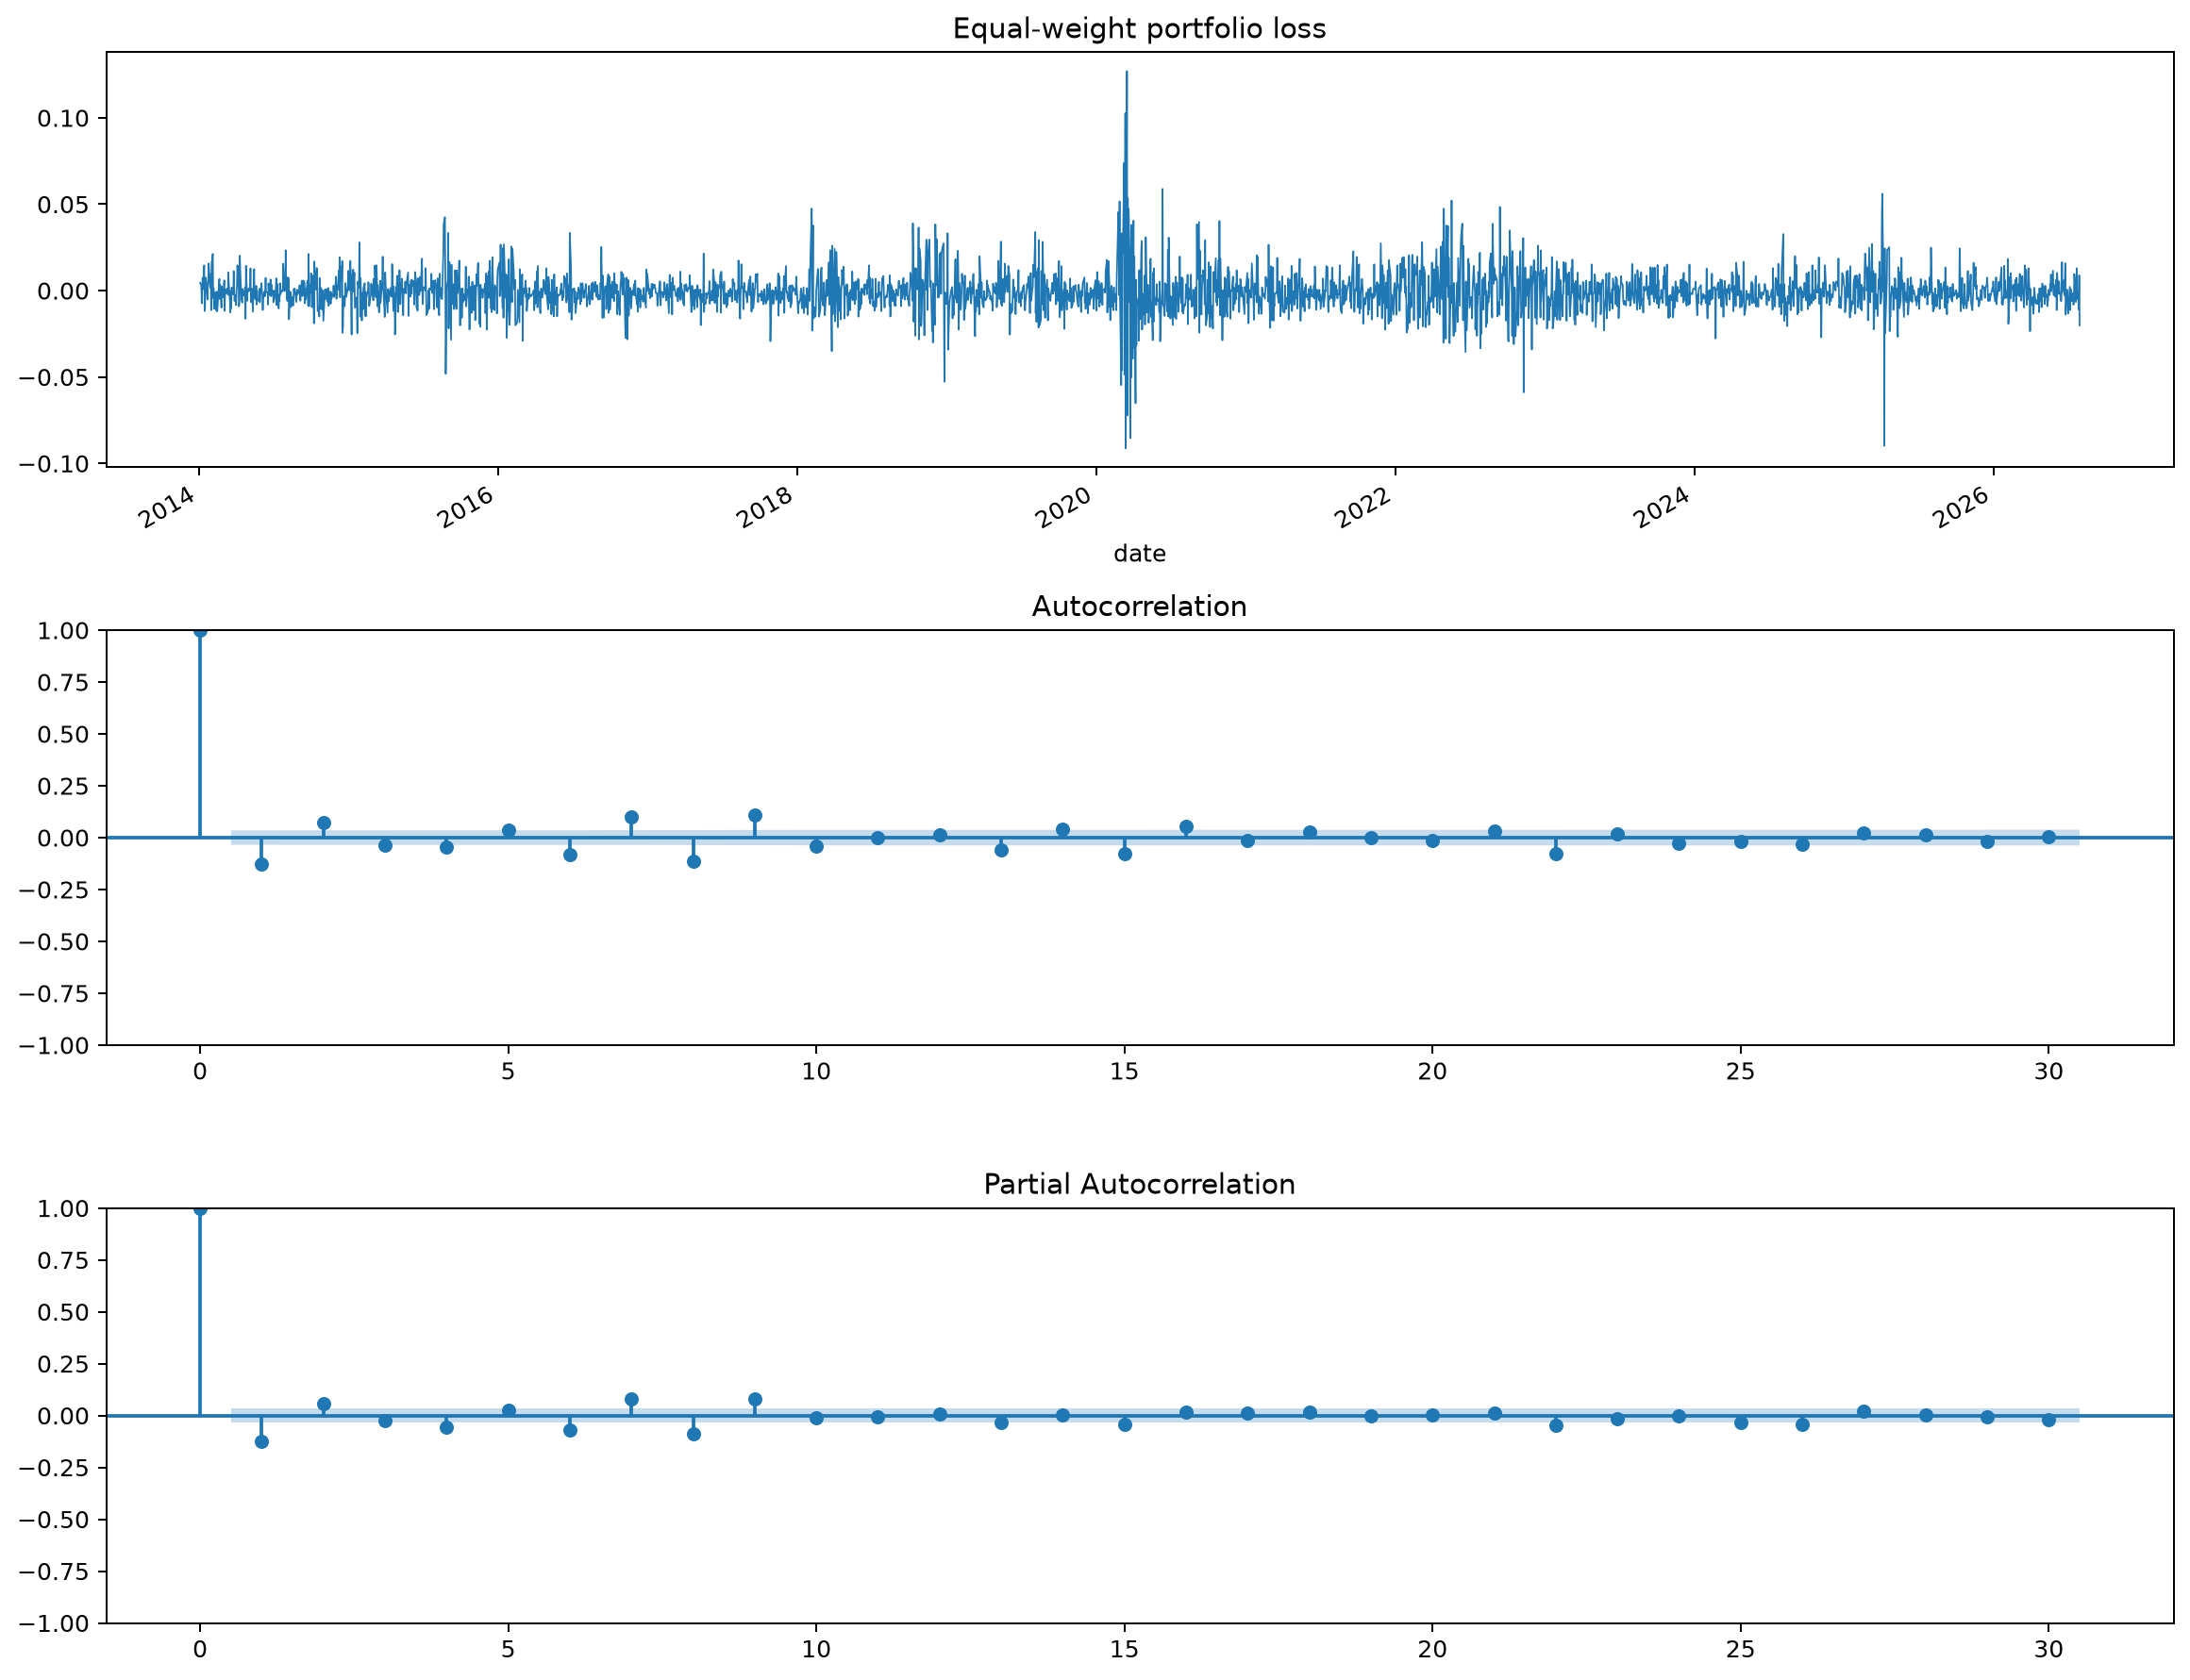

In [2]:
display(Markdown("### Loss-series distribution\nEstablish scale, asymmetry and tail behavior before fitting autoregressive models."))
display(load_result_table("robustness_ar_loss_summary.csv", index_col=0))
display(Markdown("### Stationarity evidence\nUse ADF results to assess whether level autoregressions have a stable time-series basis."))
display(load_result_table("robustness_ar_adf.csv", index_col=0))
display(Markdown("### Time-series diagnostics\nInspect persistence, volatility clustering and other features not captured by summary statistics."))
display(Image(filename=result_figure_path("robustness_ar_time_series_diagnostics.png")))

## Validation and out-of-sample forecasts

### Validation and lag-order selection
Check which specification is selected using past validation data before viewing test outcomes.

,,RMSE,MAE,Correlation,phi,AIC,BIC
model,lags,,,,,,
Linear AR,1,0.009426,0.006874,0.093592,NaN,NaN,NaN
Choquet AR,1,0.009426,0.006874,0.093592,-0.015528,-2331.986629,-2316.579567
Linear AR,2,0.009418,0.006873,0.111902,NaN,NaN,NaN
Choquet AR,2,0.009417,0.006873,0.113915,-0.034272,-2325.674580,-2300.000126
Linear AR,3,0.009414,0.006875,0.116499,NaN,NaN,NaN
Choquet AR,3,0.009433,0.006872,0.066567,-0.022435,-2316.782135,-2275.709386
Linear AR,5,0.009440,0.006907,0.028081,NaN,NaN,NaN
Choquet AR,5,0.009417,0.006872,0.105433,-0.066798,-2294.680217,-2207.427759


### Held-out forecast performance
Compare OOS errors only after the validation decision has been fixed.

,RMSE,MAE,Correlation
Choquet AR,0.013152,0.008575,6.399163e-02
Linear AR,0.013168,0.008589,2.921345e-02
Historical mean,0.013173,0.008581,-1.004369e-17


### HAC model comparison
Assess whether forecast-loss differences remain meaningful under serial dependence.

,reference,mean loss difference,standard error,lower 95%,upper 95%,favors model
model,,,,,,
Linear AR,Choquet AR,4.100495e-07,5.724511e-07,-7.119341e-07,0.000002,False
Historical mean,Choquet AR,5.511012e-07,3.292346e-07,-9.418669e-08,0.000001,False


### Forecast paths and errors
Locate when predictions diverge and whether errors cluster around volatile episodes.

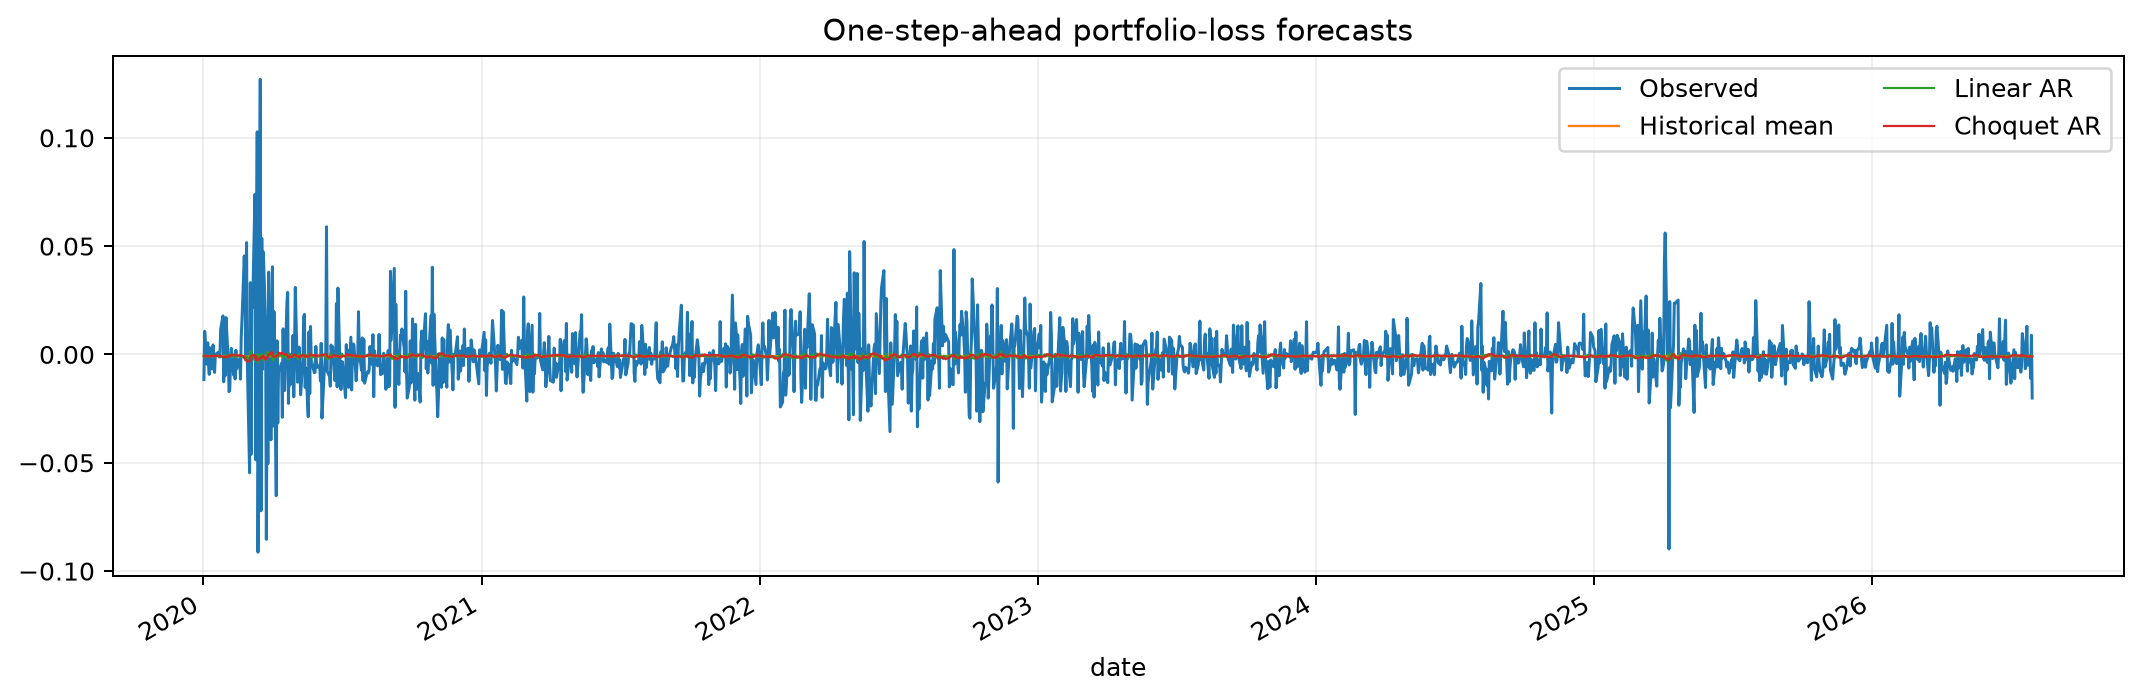

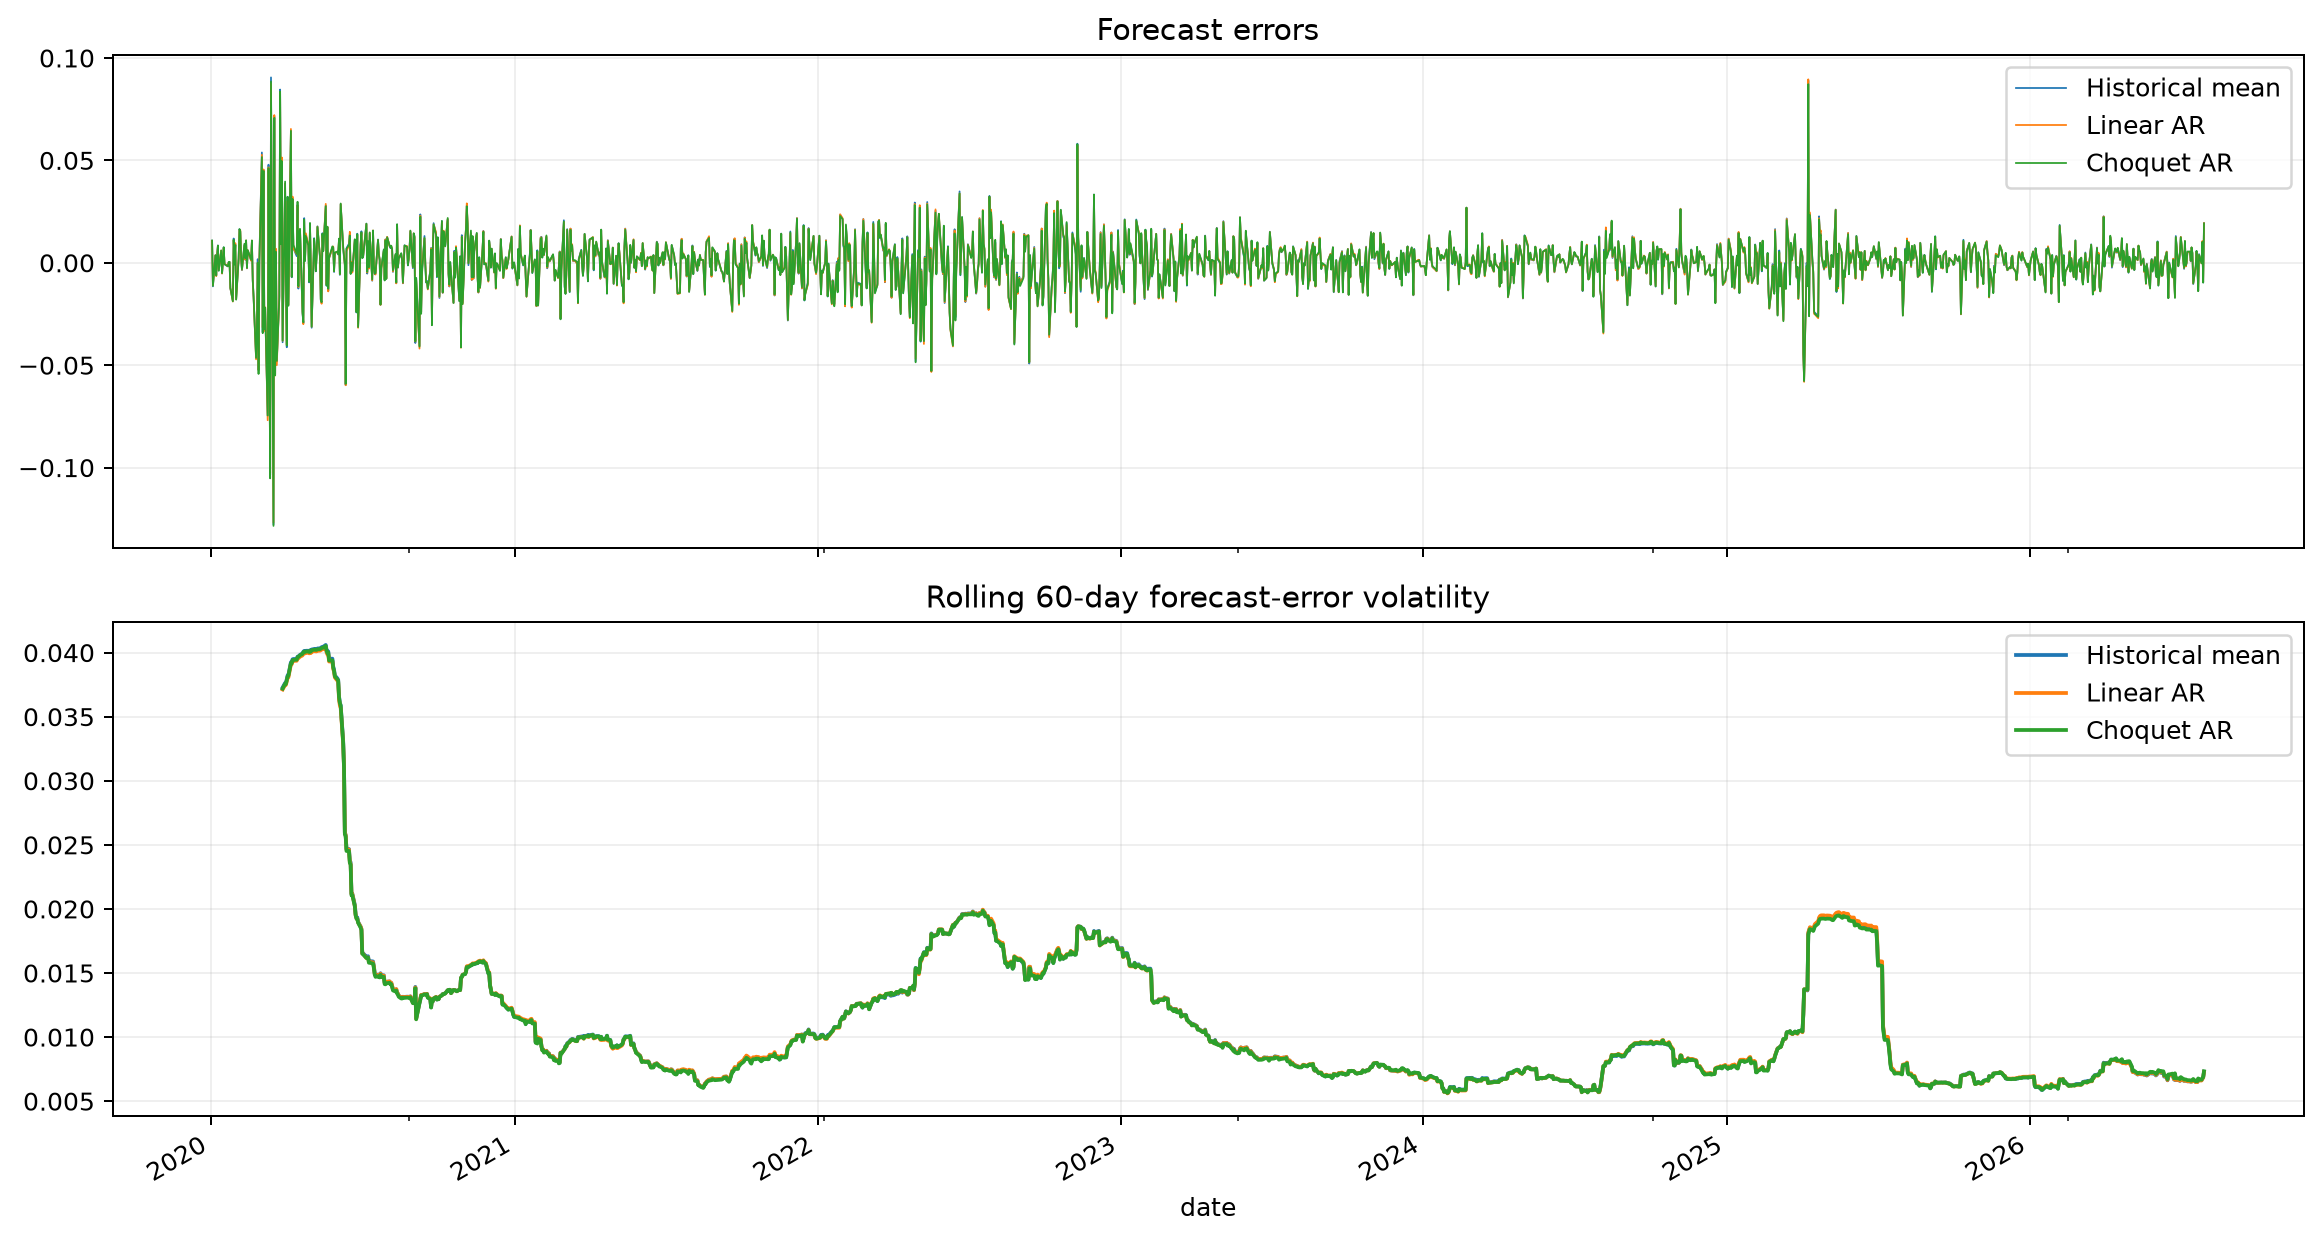

In [3]:
display(Markdown("### Validation and lag-order selection\nCheck which specification is selected using past validation data before viewing test outcomes."))
display(load_result_table("robustness_ar_validation.csv", index_col=[0, 1]))
display(Markdown("### Held-out forecast performance\nCompare OOS errors only after the validation decision has been fixed."))
display(load_result_table("robustness_ar_test_metrics.csv", index_col=0))
display(Markdown("### HAC model comparison\nAssess whether forecast-loss differences remain meaningful under serial dependence."))
display(load_result_table("robustness_ar_hac_comparison.csv", index_col=0))
display(Markdown("### Forecast paths and errors\nLocate when predictions diverge and whether errors cluster around volatile episodes."))
display(Image(filename=result_figure_path("robustness_ar_forecasts.png")))
display(Image(filename=result_figure_path("robustness_ar_forecast_errors.png")))

## Lag capacity and high-volatility performance

### Selected model details
Review lag order, complexity and fitted specification before interpreting the capacity.

,value
selected linear lags,3
selected Choquet lags,5
Choquet phi,-0.0911597081126982
stationarity bound respected,True


### Lag importance and interactions
Use Shapley values for individual lags and interaction indices for nonlinear lag combinations.

,Shapley importance
lag_1,0.2
lag_2,0.2
lag_3,0.2
lag_4,0.2
lag_5,0.2


,lag_1,lag_2,lag_3,lag_4,lag_5
lag_1,0.000000e+00,-1.387779e-17,-1.387779e-17,-1.387779e-17,-1.387779e-17
lag_2,-1.387779e-17,0.000000e+00,-1.387779e-17,-1.387779e-17,-1.387779e-17
lag_3,-1.387779e-17,-1.387779e-17,0.000000e+00,-1.387779e-17,-1.387779e-17
lag_4,-1.387779e-17,-1.387779e-17,-1.387779e-17,0.000000e+00,-1.387779e-17
lag_5,-1.387779e-17,-1.387779e-17,-1.387779e-17,-1.387779e-17,0.000000e+00


### High-volatility robustness
Check whether average OOS conclusions survive when conditioning on high-VIX observations.

,RMSE all,RMSE top-VIX decile,MAE top-VIX decile,top-VIX observations
model,,,,
Linear AR,0.013168,0.030064,0.021716,167
Choquet AR,0.013152,0.030069,0.021705,167
Historical mean,0.013173,0.030132,0.021774,167


### Capacity visualizations
The plots make relative lag importance and interaction structure easier to compare.

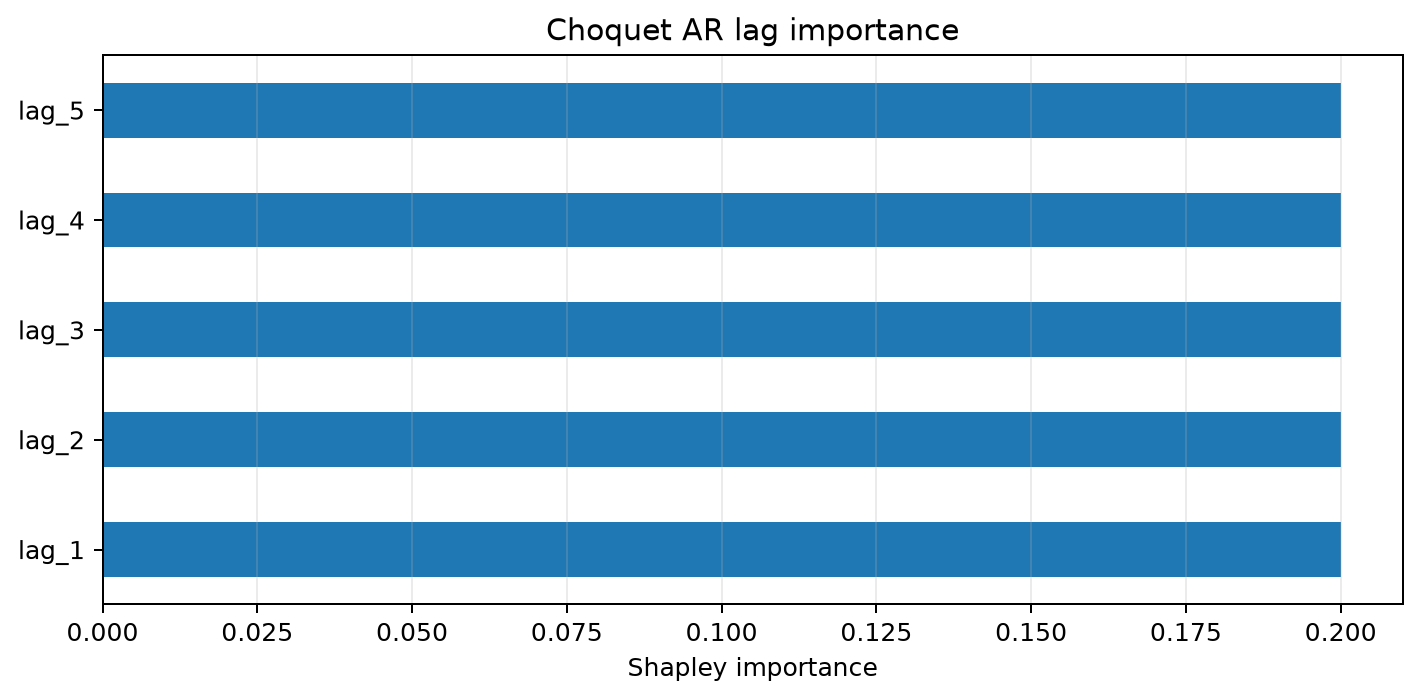

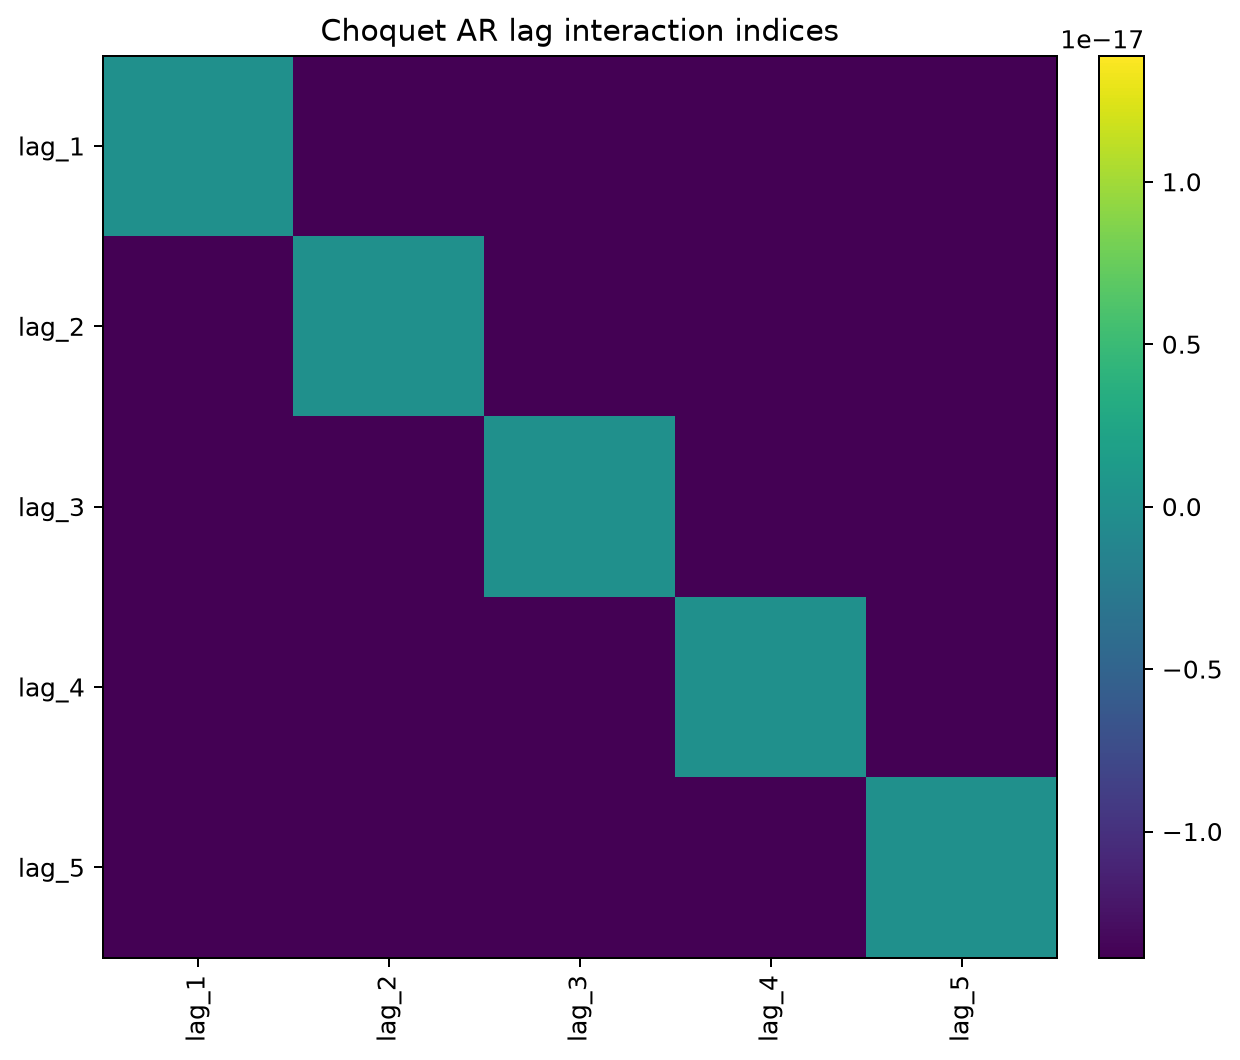

In [4]:
display(Markdown("### Selected model details\nReview lag order, complexity and fitted specification before interpreting the capacity."))
display(load_result_table("robustness_ar_model_details.csv", index_col=0))
display(Markdown("### Lag importance and interactions\nUse Shapley values for individual lags and interaction indices for nonlinear lag combinations."))
display(load_result_table("robustness_ar_shapley.csv", index_col=0))
display(load_result_table("robustness_ar_interactions.csv", index_col=0))
display(Markdown("### High-volatility robustness\nCheck whether average OOS conclusions survive when conditioning on high-VIX observations."))
display(load_result_table("robustness_ar_high_vix_metrics.csv", index_col=0))
display(Markdown("### Capacity visualizations\nThe plots make relative lag importance and interaction structure easier to compare."))
display(Image(filename=result_figure_path("robustness_ar_shapley.png")))
display(Image(filename=result_figure_path("robustness_ar_interactions.png")))